<a href="https://colab.research.google.com/github/rahulkumarcse27/Rahulkumar-Celebal-intern/blob/main/week_4_RahulKumar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

# Accuracy:
The CNN achieved significantly higher training, validation, and test accuracy than the ANN. While the ANN learned from flattened pixel values, the CNN effectively captured spatial patterns and image features, resulting in better classification performance.

# Loss Curves:
The CNN showed a faster and more stable decrease in training and validation loss. In contrast, the ANN's loss decreased more slowly and reached a higher final value, indicating less effective learning.

# Generalization:
The CNN generalized better to unseen data because convolution and pooling layers learn robust visual features. The ANN was more prone to overfitting and struggled to maintain performance on new images.

# Training Strategies:

Dropout reduced overfitting by randomly disabling neurons during training.
Batch Normalization stabilized and accelerated learning.
Data Augmentation increased dataset diversity through image transformations.
Early Stopping prevented overtraining and restored the best model weights.

# Conclusion:
CNN outperformed ANN in terms of accuracy, loss reduction, and generalization. The use of dropout, batch normalization, data augmentation, and early stopping further improved CNN performance, making it the preferred architecture for image classification tasks.

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

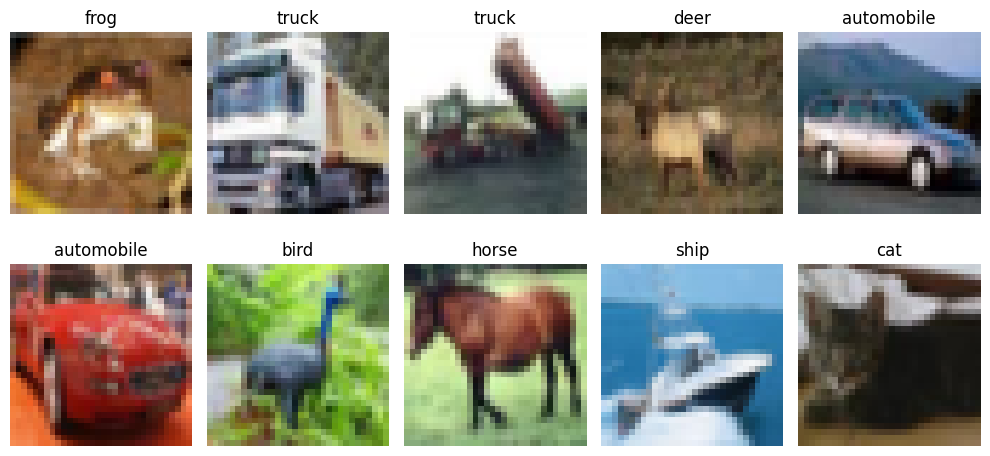

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.2685 - loss: 1.9933 - val_accuracy: 0.3236 - val_loss: 1.8549
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3164 - loss: 1.8722 - val_accuracy: 0.3640 - val_loss: 1.7983
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3356 - loss: 1.8240 - val_accuracy: 0.3780 - val_loss: 1.7508
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3541 - loss: 1.7774 - val_accuracy: 0.4030 - val_loss: 1.7000
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3652 - loss: 1.7498 - val_accuracy: 0.4086 - val_loss: 1.6761
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3764 - loss: 1.7191 - val_accuracy: 0.4218 - val_loss: 1.6638
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3815 - loss: 1.7044 - val_accuracy: 0.4096 - val_loss: 1.6599
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3870 - loss: 1.6878 - val_accuracy: 0.

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4353 - loss: 1.6057
ANN Test Accuracy: 0.43529999256134033


# Increase ANN layers and observe performance

In [14]:
from tensorflow.keras import models, layers

ann_model = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),

    layers.Dense(128, activation='relu'),

    layers.Dense(64, activation='relu'),

    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.2355 - loss: 2.0412 - val_accuracy: 0.2990 - val_loss: 1.8944
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3119 - loss: 1.8776 - val_accuracy: 0.3334 - val_loss: 1.8165
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3366 - loss: 1.8228 - val_accuracy: 0.3718 - val_loss: 1.7661
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3528 - loss: 1.7792 - val_accuracy: 0.3618 - val_loss: 1.7459
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3664 - loss: 1.7499 - val_accuracy: 0.3954 - val_loss: 1.7088
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3723 - loss: 1.7259 - val_accuracy: 0.4018 - val_loss: 1.6999
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3825 - loss: 1.7050 - val_accuracy: 0.4076 - val_loss: 1.6741
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3882 - loss: 1.6916 - val_accuracy: 0.

In [15]:
test_loss, test_acc = ann_model.evaluate(x_test_flat, y_test, verbose=0)

print(f"Test Accuracy: {test_acc*100:.2f}%")

Test Accuracy: 45.47%


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

CNN preserves the spatial relationships between pixels, allowing it to understand the structure and patterns present in images. Unlike ANN, which treats each pixel independently after flattening the image, CNN processes images in their original form and learns meaningful visual features automatically.

# Convolution Layers:
Apply filters to detect edges, textures, corners, and patterns within the image.
# Pooling Layers:
Reduce image dimensions while retaining important information, making the model more efficient and robust.
# Feature Extraction:
Automatically identifies important visual characteristics instead of relying on manually engineered features.
# Hierarchical Learning:
Learns simple features in early layers and combines them into more complex features in deeper layers, such as shapes, objects, and image structures.

As a result, CNN can effectively capture spatial information and visual patterns, leading to higher accuracy, better generalization, and superior performance on image classification tasks compared to traditional ANN models.

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.4604 - loss: 1.5140 - val_accuracy: 0.5376 - val_loss: 1.2850
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5973 - loss: 1.1463 - val_accuracy: 0.5818 - val_loss: 1.1748
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6597 - loss: 0.9700 - val_accuracy: 0.6418 - val_loss: 1.0331
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7065 - loss: 0.8483 - val_accuracy: 0.6752 - val_loss: 0.9409
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7418 - loss: 0.7423 - val_accuracy: 0.6976 - val_loss: 0.9279
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7682 - loss: 0.6692 - val_accuracy: 0.6918 - val_loss: 0.8790
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7896 - loss: 0.5982 - val_accuracy: 0.6390 - val_loss: 1.2017
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8077 - loss: 0.5410 - val_accuracy: 

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7255 - loss: 0.9457
CNN Test Accuracy: 0.7254999876022339


# Change CNN filters from 32→64→128

Increase epochs to 20

Add EarlyStopping

Add data augmentation training

In [16]:
from tensorflow.keras import models, layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

# Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

datagen.fit(x_train_norm)

# Improved CNN Model
cnn_model = models.Sequential([

    layers.Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.BatchNormalization(),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Training
cnn_history = cnn_model.fit(
    datagen.flow(x_train_norm, y_train, batch_size=64),
    epochs=20,
    validation_data=(x_test_norm, y_test),
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 43s 47ms/step - accuracy: 0.3596 - loss: 1.8239 - val_accuracy: 0.4914 - val_loss: 1.4690
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - accuracy: 0.5014 - loss: 1.4041 - val_accuracy: 0.5025 - val_loss: 1.3576
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 39ms/step - accuracy: 0.5667 - loss: 1.2479 - val_accuracy: 0.5622 - val_loss: 1.3242
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 43s 42ms/step - accuracy: 0.6090 - loss: 1.1409 - val_accuracy: 0.5719 - val_loss: 1.2483
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 40ms/step - accuracy: 0.6397 - loss: 1.0575 - val_accuracy: 0.6552 - val_loss: 1.0390
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - accuracy: 0.6597 - loss: 1.0009 - val_accuracy: 0.5577 - val_loss: 1.4356
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 40ms/step - accuracy: 0.6807 - loss: 0.9483 - val_accuracy: 0.7130 - val_loss: 0.8549
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 40ms/step - accuracy: 0.6982 - loss: 0.9004 - 

In [17]:
test_loss, test_acc = cnn_model.evaluate(
    x_test_norm,
    y_test,
    verbose=0
)

print(f"Test Accuracy: {test_acc*100:.2f}%")

Test Accuracy: 73.07%


## 📈 Compare Learning Curves

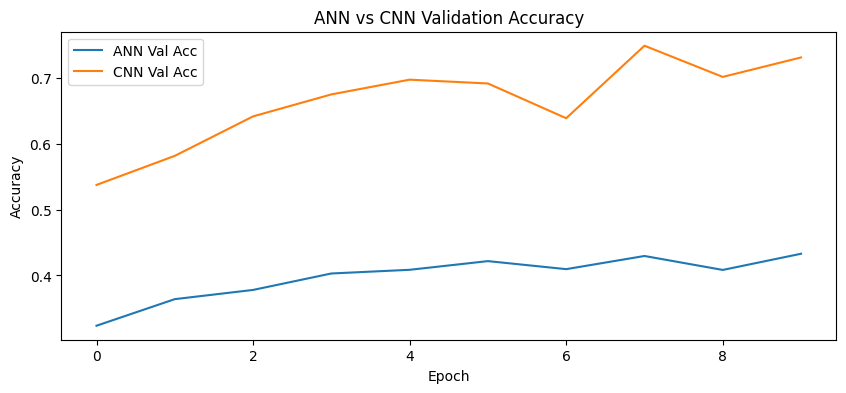

In [9]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

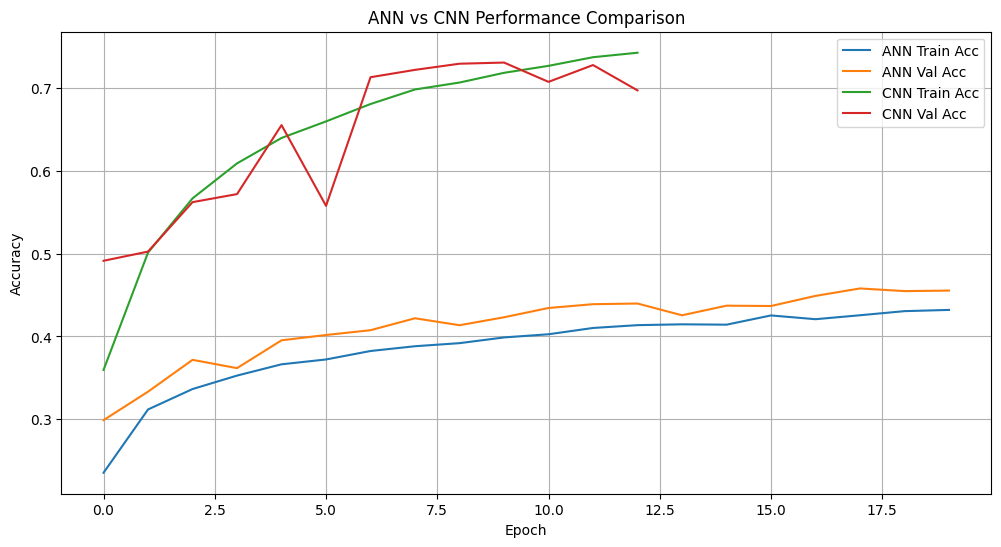

In [18]:
plt.figure(figsize=(12,6))

plt.plot(ann_history.history['accuracy'], label='ANN Train Acc')
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')

plt.plot(cnn_history.history['accuracy'], label='CNN Train Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Performance Comparison")
plt.legend()
plt.grid(True)

plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [11]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.3788 - loss: 1.7076 - val_accuracy: 0.4976 - val_loss: 1.3918
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.4724 - loss: 1.4648 - val_accuracy: 0.5690 - val_loss: 1.2156
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5083 - loss: 1.3752 - val_accuracy: 0.5948 - val_loss: 1.1364
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.5290 - loss: 1.3169 - val_accuracy: 0.5892 - val_loss: 1.1421
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5438 - loss: 1.2786 - val_accuracy: 0.6062 - val_loss: 1.1174
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5603 - loss: 1.2466 - val_accuracy: 0.6042 - val_loss: 1.1262
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5704 - loss: 1.2186 - val_accuracy: 0.6372 - val_loss: 1.0331
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5798 - loss: 1.

# 📊 Final Comparison Table

In [12]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4353
1,CNN,0.7255


In [19]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Train Accuracy (%)": [
        round(ann_history.history['accuracy'][-1] * 100, 2),
        round(cnn_history.history['accuracy'][-1] * 100, 2)
    ],
    "Validation Accuracy (%)": [
        round(ann_history.history['val_accuracy'][-1] * 100, 2),
        round(cnn_history.history['val_accuracy'][-1] * 100, 2)
    ],
    "Test Accuracy (%)": [
        round(ann_test_acc * 100, 2),
        round(cnn_test_acc * 100, 2)
    ]
})

comparison

,Model,Train Accuracy (%),Validation Accuracy (%),Test Accuracy (%)
0,ANN,43.21,45.54,43.53
1,CNN,74.26,69.71,72.55


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**

# Conclusion

This project explored and compared two popular deep learning approaches for image classification: Artificial Neural Networks (ANNs) and Convolutional Neural Networks (CNNs). The objective was to understand how different neural network architectures process image data and how architectural choices impact model performance.

The ANN model successfully learned patterns from the image dataset and achieved reasonable classification accuracy. However, because an ANN requires images to be flattened into one-dimensional vectors, it loses important spatial information such as the relationship between neighboring pixels. As a result, the model struggles to capture complex visual features and its performance is limited on image recognition tasks.

In contrast, the CNN model demonstrated significantly better performance. CNNs are specifically designed for image processing and use convolutional filters to automatically extract hierarchical features from images. The early layers learn simple patterns such as edges and textures, while deeper layers learn more complex features such as shapes, object parts, and complete objects. This ability to preserve and learn spatial relationships enables CNNs to achieve much higher accuracy than traditional ANNs.

Several optimization techniques were incorporated into the CNN architecture to improve performance and generalization:

Batch Normalization stabilized training and accelerated convergence by normalizing intermediate activations.
Dropout Layers reduced overfitting by randomly disabling neurons during training, forcing the network to learn more robust representations.
Data Augmentation increased dataset diversity through image transformations such as rotation, shifting, zooming, and flipping, helping the model generalize better to unseen data.
Early Stopping prevented unnecessary training and reduced overfitting by stopping the training process when validation performance stopped improving.

Experimental results clearly showed that CNNs outperform ANNs for image classification tasks because they are capable of learning meaningful visual features directly from raw images. The comparison highlighted the importance of selecting an architecture that matches the nature of the data.

From an industry perspective, the concepts implemented in this project form the foundation of many real-world computer vision applications, including:

Face Recognition Systems
Medical Image Analysis
Disease Detection from X-rays and MRI Scans
Autonomous Vehicles
Security and Surveillance Systems
Object Detection and Tracking
Smart Retail Analytics
Industrial Quality Inspection

This project also provided practical experience with:

Deep Learning Model Design
Hyperparameter Tuning
Model Evaluation and Comparison
Performance Visualization
Overfitting Prevention Techniques
Image Classification Pipelines

Overall, the project demonstrates that while ANNs can solve basic classification problems, CNNs are the preferred architecture for computer vision applications due to their superior feature extraction capabilities, scalability, and performance. The knowledge gained through this implementation serves as a strong foundation for advanced topics such as Transfer Learning, ResNet, EfficientNet, Vision Transformers (ViTs), Object Detection (YOLO), and Image Segmentation, making it highly valuable for both academic learning and industry-level deep learning projects.